# CMPE 252 Project 2: Neural Machine Translation with Attention


## Project Summary

This notebook implements a neural machine translation (NMT) system that translates English to Spanish using a Transformer encoder-decoder architecture trained from scratch in PyTorch. Attention is implemented through the Transformer's multi-head self attention and encoder–decoder cross-attention mechanisms.

**Dataset:** WMT English–Spanish parallel data from the News Commentary subset, sampled to a Colab-scale full run.

**Metric:** SacreBLEU corpus BLEU score.

**Goal:** Work toward a BLEU score of 80–85 BLEU through documented hyperparameter tuning,
starting from a small baseline and improving iteratively.

## What was Covered in this Notebook

| # | Requirement | Where Addressed |
|---|-------------|-----------------|
| 1 | Use WMT dataset for NMT with attention | Section 5 Dataset Loading, Section 9 Transformer Model |
| 2 | Split into train / test (minimum) | Section 5 Dataset Loading (train / val / test split) |
| 3 | Any architecture allowed | Section 9 Transformer Encoder–Decoder |
| 4 | Attention mechanism required | Section 9 Multi-head self-attention & cross-attention |
| 5 | Goal: Work toward 80–85 BLEU | Section 11 BLEU Evaluation, Section 13 Tuning, Section 17 Results |

### Additional Clarifications/Requirements

| # | Clarification | Where Addressed |
|---|---------------|-----------------|
| 1 | Use BLEU as metric | Section 11 SacreBLEU evaluation throughout |
| 2 | 80–85 BLEU is a goal, not a strict minimum | Section 17 Results |
| 3 | Start with a baseline, then tune | Section 12 Baseline → Section 13 Tuning experiments |
| 4 | Document improvement process | Section 13 Experiment table, Section 15 Plots |

---

## 4. Environment Setup

This section installs all required packages, sets reproducible random seeds,
detects the GPU, mounts Google Drive for checkpoint persistence, and prints
package versions for reproducibility.

In [2]:
# ── 4a. Install packages ──────────────────────────────────────────────
# NOTE: Restart the runtime after first install if prompted by Colab.
!pip install -q sentencepiece sacrebleu 'mtdata==0.4.2' pandas matplotlib tqdm scikit-learn

In [3]:
# ── 4b. Imports ──────────────────────────────────────────────────────
import os
import re
import sys
import math
import time
import random
import json
import warnings
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import sentencepiece as spm
import sacrebleu
from tqdm.auto import tqdm
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
matplotlib.rcParams["figure.dpi"] = 120
matplotlib.rcParams["figure.figsize"] = (8, 4)

print("Imports complete.")

Imports complete.


In [4]:
# ── 4c. Reproducible random seeds ────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Random seed set to {SEED}.")

Random seed set to 42.


In [5]:
# --- 4d. GPU detection ----------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device : {device}")

if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = gpu_props.total_memory / 1e9

    print(f"GPU    : {gpu_name}")
    print(f"Memory : {gpu_memory_gb:.1f} GB")
else:
    print("⚠️ No GPU detected, training will be very slow.")
    print("Go to Runtime → Change runtime type → GPU.")

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
Memory : 85.1 GB


In [6]:
# ── 4e. Mount Google Drive ────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    IN_COLAB = True
    print("Google Drive mounted.")
except ImportError:
    IN_COLAB = False
    print("Not running in Colab, Google Drive not mounted.")

Mounted at /content/drive
Google Drive mounted.


In [7]:
# ── 4f. Project paths ────────────────────────────────────────────────
if IN_COLAB:
    PROJECT_DIR = Path("/content/drive/MyDrive/NLP_Project2")
else:
    PROJECT_DIR = Path("./NLP_Project2")

DATA_DIR   = PROJECT_DIR / "data"
CKPT_DIR   = PROJECT_DIR / "checkpoints"
SP_DIR     = PROJECT_DIR / "tokenizer"
LOG_DIR    = PROJECT_DIR / "logs"

for d in [DATA_DIR, CKPT_DIR, SP_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"  ✓ {d}")

  ✓ /content/drive/MyDrive/NLP_Project2/data
  ✓ /content/drive/MyDrive/NLP_Project2/checkpoints
  ✓ /content/drive/MyDrive/NLP_Project2/tokenizer
  ✓ /content/drive/MyDrive/NLP_Project2/logs


In [8]:
# ── 4g. Package versions ─────────────────────────────────────────────
print(f"Python         : {sys.version.split()[0]}")
print(f"PyTorch        : {torch.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Pandas         : {pd.__version__}")
print(f"SentencePiece  : {spm.__version__}")
print(f"SacreBLEU      : {sacrebleu.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")

Python         : 3.12.13
PyTorch        : 2.10.0+cu128
NumPy          : 2.0.2
Pandas         : 2.2.2
SentencePiece  : 0.2.1
SacreBLEU      : 2.6.0
Matplotlib     : 3.10.0


## 5. Dataset Loading: WMT English–Spanish

We use WMT English–Spanish parallel data for machine translation. In this final run, the notebook loaded the `Statmt-news_commentary-16-eng-spa` News Commentary subset through `mtdata`, then sampled it to a Colab-scale training size.

Strategy:

1. **mtdata preferred:** The notebook first tries to load a known WMT English–Spanish sub-corpus through `mtdata`, prioritizing News Commentary.
2. **Europarl fallback:** If `mtdata` is unavailable, the notebook can fall back to downloading the official Europarl v7 Spanish–English parallel corpus from statmt.org.

Both sources are official WMT parallel data. The notebook records the actual source used in the output so the final results are traceable.

The full WMT recipe contains far more sentence pairs than practical for a Colab project. This notebook uses a controlled single-corpus subset and clearly reports the source, sample size, split sizes, and final BLEU results.

In [9]:
# ── 5a. Data size configuration ──────────────────────────────────────
@dataclass
class DataConfig:
    '''Controls how much data we load and how we split it.'''
    SMOKE_TEST: bool = False          # True = tiny run for debugging | False = full test/run
    MAX_PAIRS_SMOKE: int = 3_000     # pairs used in smoke-test mode
    MAX_PAIRS_FULL: int = 200_000    # pairs used in full mode
    VAL_FRAC: float = 0.05           # fraction held out for validation
    TEST_FRAC: float = 0.05          # fraction held out for testing
    MIN_LEN: int = 1                 # minimum sentence length (tokens, pre-BPE)
    MAX_LEN: int = 80                # maximum sentence length (tokens, pre-BPE)

dcfg = DataConfig()

# Effective max pairs
MAX_PAIRS = dcfg.MAX_PAIRS_SMOKE if dcfg.SMOKE_TEST else dcfg.MAX_PAIRS_FULL
print(f"SMOKE_TEST = {dcfg.SMOKE_TEST}  →  MAX_PAIRS = {MAX_PAIRS:,}")

SMOKE_TEST = False  →  MAX_PAIRS = 200,000


In [10]:
# ── 5b. Download WMT English–Spanish data ────────────────────────────
# Strategy 1: mtdata, request a specific known WMT sub-corpus
# Strategy 2: Direct download of Europarl v7 es-en from statmt.org

SRC_FILE = DATA_DIR / "wmt_en_es.en"
TGT_FILE = DATA_DIR / "wmt_en_es.es"
DATA_SOURCE_FILE = DATA_DIR / "data_source.txt"

# ── Strategy 2 helper: Europarl v7 direct download ───────────────────
def download_europarl_v7():
    '''Download Europarl v7 es-en from statmt.org (official WMT training corpus).

    URL: https://www.statmt.org/europarl/v7/es-en.tgz
    Format: one sentence per line in europarl-v7.es-en.en / .es files.
    '''
    import urllib.request, tarfile
    url = "https://www.statmt.org/europarl/v7/es-en.tgz"
    tgz_path = DATA_DIR / "es-en.tgz"

    if not tgz_path.exists():
        print(f"  Downloading Europarl v7 es-en from statmt.org …")
        urllib.request.urlretrieve(url, tgz_path)
        print(f"  Downloaded {tgz_path.stat().st_size / 1e6:.1f} MB")

    # Extract the two parallel text files
    print("  Extracting …")
    with tarfile.open(tgz_path, "r:gz") as tar:
        tar.extractall(path=str(DATA_DIR))

    en_path = DATA_DIR / "europarl-v7.es-en.en"
    es_path = DATA_DIR / "europarl-v7.es-en.es"

    if not en_path.exists() or not es_path.exists():
        # Some archives nest files, search for them
        for p in DATA_DIR.rglob("europarl-v7.es-en.en"):
            en_path = p
        for p in DATA_DIR.rglob("europarl-v7.es-en.es"):
            es_path = p

    en_lines = en_path.read_text(encoding="utf-8", errors="replace").strip().split("\n")
    es_lines = es_path.read_text(encoding="utf-8", errors="replace").strip().split("\n")

    source_label = "Europarl v7 es-en (statmt.org, official WMT training corpus)"
    return en_lines, es_lines, source_label

# ── Strategy 1 helper: mtdata with specific dataset IDs ──────────────
# We try several known good mtdata IDs in order of preference.
MTDATA_CANDIDATES = [
    "Statmt-news_commentary-16-eng-spa",   # News Commentary v16 (≈370k pairs)
    "Statmt-news_commentary-18.1-eng-spa", # News Commentary v18.1
    "Statmt-europarl-10-eng-spa",          # Europarl v10 via mtdata
    "Statmt-europarl-7-spa-eng",           # Europarl v7 via mtdata
]

def try_mtdata():
    '''Try mtdata to download a known WMT eng-spa sub-corpus.'''
    try:
        import subprocess

        # Step 1, verify mtdata works
        result = subprocess.run(
            ["mtdata", "list", "-l", "eng-spa"],
            capture_output=True, text=True, timeout=120
        )
        if result.returncode != 0:
            print(f"  mtdata list failed (exit {result.returncode}).")
            return None, None, None

        available_text = result.stdout.lower()
        available_ids = [l.split()[0] for l in result.stdout.strip().split("\n") if l.strip()]
        print(f"  mtdata lists {len(available_ids)} eng-spa entries.")

        # Step 2, pick the first available candidate
        target = None
        for cand in MTDATA_CANDIDATES:
            if cand.lower() in available_text or cand in available_ids:
                target = cand
                break
        # Fallback: search for any news_commentary or europarl
        if target is None:
            for aid in available_ids:
                low = aid.lower()
                if "news_commentary" in low or "news-commentary" in low:
                    target = aid
                    break
            if target is None:
                for aid in available_ids:
                    if "europarl" in aid.lower():
                        target = aid
                        break

        if target is None:
            print("  No suitable sub-corpus found in mtdata listing.")
            return None, None, None

        print(f"  Selected: {target}")

        # Step 3, download
        out_dir = DATA_DIR / "mtdata_out"
        out_dir.mkdir(exist_ok=True)
        dl = subprocess.run(
            ["mtdata", "get", "-l", "eng-spa", "-tr", target, "-o", str(out_dir)],
            capture_output=True, text=True, timeout=900
        )
        if dl.returncode != 0:
            print(f"  mtdata get failed: {dl.stderr[:300]}")
            return None, None, None

        # Step 4, locate output files
        search_dirs = [out_dir / "train-parts", out_dir]
        en_file = es_file = None
        for d in search_dirs:
            if not d.exists():
                continue
            for f in sorted(d.iterdir()):
                nm = f.name.lower()
                if f.is_file() and f.stat().st_size > 100:
                    if ("eng" in nm or f.suffix == ".en") and en_file is None:
                        en_file = f
                    elif ("spa" in nm or f.suffix == ".es") and es_file is None:
                        es_file = f

        if en_file and es_file:
            en_lines = en_file.read_text(encoding="utf-8").strip().split("\n")
            es_lines = es_file.read_text(encoding="utf-8").strip().split("\n")
            source_label = f"mtdata: {target}"
            print(f"  Got {len(en_lines):,} EN / {len(es_lines):,} ES lines.")
            return en_lines, es_lines, source_label
        else:
            found = [f.name for f in out_dir.rglob("*") if f.is_file()][:15]
            print(f"  Could not locate en/es files. Found: {found}")
            return None, None, None

    except Exception as e:
        print(f"  mtdata attempt failed: {e}")
        return None, None, None

# ── Main download logic ──────────────────────────────────────────────
if SRC_FILE.exists() and TGT_FILE.exists():
    print("Cached data files found on Drive — loading from cache.")
    en_lines = SRC_FILE.read_text(encoding="utf-8").strip().split("\n")
    es_lines = TGT_FILE.read_text(encoding="utf-8").strip().split("\n")
    data_source = DATA_SOURCE_FILE.read_text().strip() if DATA_SOURCE_FILE.exists() else "(cached, source unknown)"
    print(f"  {len(en_lines):,} EN / {len(es_lines):,} ES lines.")
    print(f"  Source: {data_source}")
else:
    en_lines, es_lines, data_source = None, None, None

    # Strategy 1: mtdata
    print("Strategy 1: Trying mtdata for WMT eng-spa …")
    en_lines, es_lines, data_source = try_mtdata()

    # Strategy 2: Europarl v7 direct download
    if en_lines is None:
        print("\nStrategy 2: Downloading Europarl v7 es-en from statmt.org …")
        print("  (Europarl is an official WMT shared-task training corpus.)")
        en_lines, es_lines, data_source = download_europarl_v7()

    print(f"\nTotal raw parallel sentences: {len(en_lines):,}")
    print(f"Data source: {data_source}")

    # Cache to Drive for future runs
    SRC_FILE.write_text("\n".join(en_lines), encoding="utf-8")
    TGT_FILE.write_text("\n".join(es_lines), encoding="utf-8")
    DATA_SOURCE_FILE.write_text(data_source, encoding="utf-8")
    print("Cached to Google Drive.")

Cached data files found on Drive — loading from cache.
  369,540 EN / 369,540 ES lines.
  Source: mtdata: Statmt-news_commentary-16-eng-spa


In [11]:
# ── 5c. Sanity check: show raw samples ───────────────────────────────
print(f"Total raw pairs: {len(en_lines):,}\n")
print("── Sample sentence pairs (raw) ──")
for i in range(min(5, len(en_lines))):
    print(f"  EN: {en_lines[i][:250]}")
    print(f"  ES: {es_lines[i][:250]}")
    print()

Total raw pairs: 369,540

── Sample sentence pairs (raw) ──
  EN: $10,000 Gold?
  ES: ¿El oro a 10.000 dólares?

  EN: SAN FRANCISCO – It has never been easy to have a rational conversation about the value of gold.
  ES: SAN FRANCISCO – Nunca ha resultado fácil sostener una conversación racional sobre el valor del oro.

  EN: Lately, with gold prices up more than 300% over the last decade, it is harder than ever.
  ES: Últimamente, con los precios del oro más de un 300% por encima de los de la década pasada, resulta más difícil que nunca.

  EN: Just last December, fellow economists Martin Feldstein and Nouriel Roubini each penned op-eds bravely questioning bullish market sentiment, sensibly pointing out gold’s risks.
  ES: Apenas en el pasado mes de diciembre, mis colegas los economistas Martin Feldstein y Nouriel Roubini escribieron columnas de opinión cuestionando valientemente el sentimiento alcista del mercado, y señalando con criterio los riesgos del oro.

  EN: Wouldn’t you know

In [12]:
# ── 5d. Sample, clean, and deduplicate ────────────────────────────────
# We clean and deduplicate the ENTIRE dataset BEFORE splitting into
# train/val/test so that (a) cleaning cannot create cross-split duplicates,
# and (b) every split sees only clean, unique sentence pairs.

assert len(en_lines) == len(es_lines), "Mismatch in line counts!"

# ── Sample to MAX_PAIRS ──────────────────────────────────────────────
if len(en_lines) > MAX_PAIRS:
    set_seed(SEED)
    indices = list(range(len(en_lines)))
    random.shuffle(indices)
    indices = sorted(indices[:MAX_PAIRS])
    en_lines = [en_lines[i] for i in indices]
    es_lines = [es_lines[i] for i in indices]
    print(f"Sampled {MAX_PAIRS:,} pairs.")
else:
    print(f"Using all {len(en_lines):,} pairs (fewer than MAX_PAIRS).")

# ── Clean (whitespace normalization + length filtering) ──────────────
def clean_line(s: str) -> str:
    '''Normalize whitespace and strip.'''
    return re.sub(r"\s+", " ", s).strip()

clean_en, clean_es = [], []
dropped = 0
for en, es in zip(en_lines, es_lines):
    en_c, es_c = clean_line(en), clean_line(es)
    if not en_c or not es_c:
        dropped += 1
        continue
    en_wc, es_wc = len(en_c.split()), len(es_c.split())
    if en_wc < dcfg.MIN_LEN or es_wc < dcfg.MIN_LEN:
        dropped += 1
        continue
    if en_wc > dcfg.MAX_LEN or es_wc > dcfg.MAX_LEN:
        dropped += 1
        continue
    clean_en.append(en_c)
    clean_es.append(es_c)

print(f"Dropped {dropped} pairs during cleaning (empty / too short / too long).")

# ── Deduplicate (exact-match on normalized pair) ─────────────────────
seen = set()
dedup_en, dedup_es = [], []
for en, es in zip(clean_en, clean_es):
    key = (en, es)
    if key not in seen:
        seen.add(key)
        dedup_en.append(en)
        dedup_es.append(es)

n_dupes = len(clean_en) - len(dedup_en)
en_lines = dedup_en
es_lines = dedup_es
print(f"Removed {n_dupes} duplicate pairs.")
print(f"Clean, unique dataset: {len(en_lines):,} pairs")

Sampled 200,000 pairs.
Dropped 443 pairs during cleaning (empty / too short / too long).
Removed 221 duplicate pairs.
Clean, unique dataset: 199,336 pairs


In [13]:
# ── 5e. Train / Validation / Test split ──────────────────────────────
from sklearn.model_selection import train_test_split

# First split: train+val vs test
en_trainval, en_test, es_trainval, es_test = train_test_split(
    en_lines, es_lines, test_size=dcfg.TEST_FRAC, random_state=SEED
)

# Second split: train vs val
val_ratio = dcfg.VAL_FRAC / (1 - dcfg.TEST_FRAC)
en_train, en_val, es_train, es_val = train_test_split(
    en_trainval, es_trainval, test_size=val_ratio, random_state=SEED
)

print(f"Train : {len(en_train):>8,} pairs")
print(f"Val   : {len(en_val):>8,} pairs")
print(f"Test  : {len(en_test):>8,} pairs")
print(f"Total : {len(en_train)+len(en_val)+len(en_test):>8,} pairs")

Train :  179,402 pairs
Val   :    9,967 pairs
Test  :    9,967 pairs
Total :  199,336 pairs


In [14]:
# ── 5f. Data leakage check ────────────────────────────────────────────
train_set = set(zip(en_train, es_train))
val_set   = set(zip(en_val, es_val))
test_set  = set(zip(en_test, es_test))

leak_tv = len(train_set & val_set)
leak_tt = len(train_set & test_set)
leak_vt = len(val_set & test_set)

print(f"Train ∩ Val  overlap: {leak_tv}")
print(f"Train ∩ Test overlap: {leak_tt}")
print(f"Val   ∩ Test overlap: {leak_vt}")
if leak_tv + leak_tt + leak_vt == 0:
    print("✓ No data leakage detected.")
else:
    print("⚠ Some overlap found after deduplication, investigate.")

Train ∩ Val  overlap: 0
Train ∩ Test overlap: 0
Val   ∩ Test overlap: 0
✓ No data leakage detected.


In [15]:
# ── 5g. Dataset statistics ────────────────────────────────────────────
def word_lengths(lines):
    return [len(s.split()) for s in lines]

stats = {
    "Split": ["Train", "Val", "Test"],
    "Pairs": [len(en_train), len(en_val), len(en_test)],
    "EN mean words": [np.mean(word_lengths(en_train)), np.mean(word_lengths(en_val)), np.mean(word_lengths(en_test))],
    "ES mean words": [np.mean(word_lengths(es_train)), np.mean(word_lengths(es_val)), np.mean(word_lengths(es_test))],
}
pd.DataFrame(stats).round(1)

,Split,Pairs,EN mean words,ES mean words
0,Train,179402,22.2,26.1
1,Val,9967,22.3,26.2
2,Test,9967,22.3,26.2


---

## 6. Data Exploration

The data was already cleaned (whitespace normalization, length filtering) and
deduplicated in Section 5d *before* splitting, which is the safest order: it prevents
cleaning from introducing cross-split duplicates. Below we inspect the cleaned
data and plot sentence-length distributions.

In [16]:
# ── 6a. Post-split verification ─────────────────────────────────────
# Cleaning and deduplication were performed in Section 5d before the split.
# Verify that the splits are still clean and non-empty.

print(f"Train: {len(en_train):,}  Val: {len(en_val):,}  Test: {len(en_test):,}")
print(f"Total: {len(en_train)+len(en_val)+len(en_test):,} clean, unique pairs")

# Quick spot-check: no empty or too-short sentences in ANY split
all_splits = [
    ("train EN", en_train),
    ("train ES", es_train),
    ("val EN", en_val),
    ("val ES", es_val),
    ("test EN", en_test),
    ("test ES", es_test),
]

for name, lines in all_splits:
    assert all(len(s.split()) >= dcfg.MIN_LEN for s in lines), (
        f"Empty or too-short sentence found in {name}!"
    )

print("✓ No empty or too-short sentences in any split.")

Train: 179,402  Val: 9,967  Test: 9,967
Total: 199,336 clean, unique pairs
✓ No empty or too-short sentences in any split.


In [17]:
# ── 6b. Sample cleaned sentence pairs ────────────────────────────────
print("— Sample cleaned sentence pairs —")
for i in range(min(3, len(en_train))):
    print(f"EN: {en_train[i][:500]}")
    print(f"ES: {es_train[i][:500]}")
    print()

— Sample cleaned sentence pairs —
EN: Indeed, for the next five to ten years, Russia will be able to fulfill its gas contracts in Europe only by monopolizing exports of gas to Europe from Kazakhstan, Turkmenistan, and Uzbekistan.
ES: En efecto, en los siguientes cinco a diez años, Rusia sólo podrá cumplir sus contratos de gas con Europa mediante la monopolización de las exportaciones de gas desde Kazajstán, Turkmenistán y Uzbekistán.

EN: For example, standardizing regulations relating to covered bonds, green bonds, and cross-border investment through real-estate trusts could encourage more long-term investment.
ES: Por ejemplo, los reglamentos de normalización relativos a los bonos cubiertos, los bonos verdes y las inversiones transfronterizas mediante sociedades de inversión inmobiliaria podrían fomentar más inversión a largo plazo.

EN: When the packages were unwrapped, most of their contents turned out to consist of pools of toxic assets for which there was no proper due diligence,

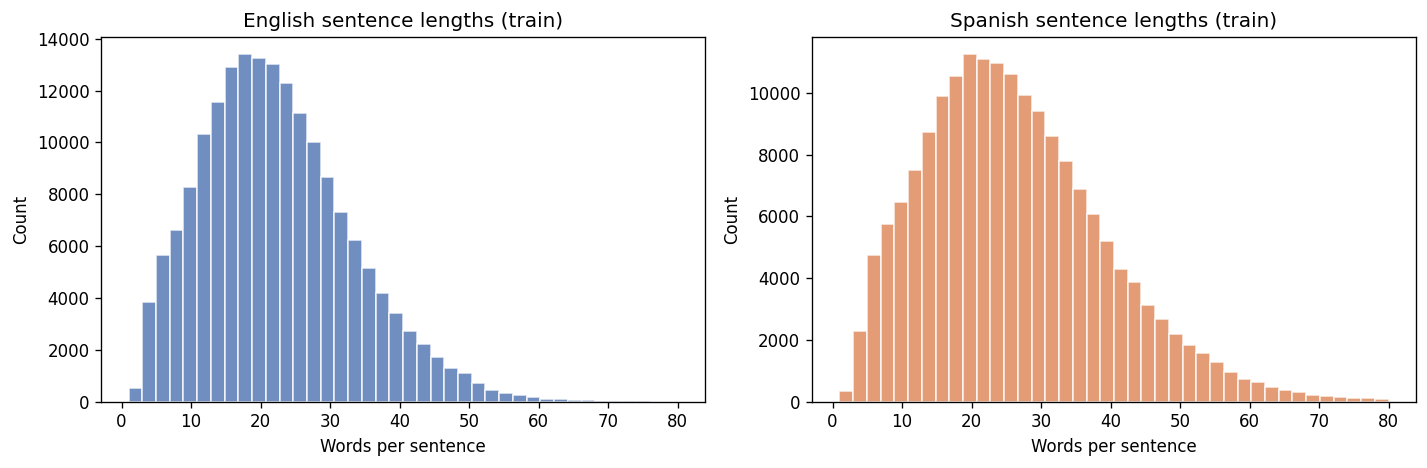

EN — mean: 22.2, median: 21, max: 80
ES — mean: 26.1, median: 25, max: 80


In [18]:
# ── 6c. Sentence length distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

en_wl = word_lengths(en_train)
es_wl = word_lengths(es_train)

axes[0].hist(en_wl, bins=40, color="#4C72B0", alpha=0.8, edgecolor="white")
axes[0].set_title("English sentence lengths (train)")
axes[0].set_xlabel("Words per sentence")
axes[0].set_ylabel("Count")

axes[1].hist(es_wl, bins=40, color="#DD8452", alpha=0.8, edgecolor="white")
axes[1].set_title("Spanish sentence lengths (train)")
axes[1].set_xlabel("Words per sentence")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(str(LOG_DIR / "sentence_lengths.png"), bbox_inches="tight")
plt.show()
print(f"EN — mean: {np.mean(en_wl):.1f}, median: {np.median(en_wl):.0f}, max: {max(en_wl)}")
print(f"ES — mean: {np.mean(es_wl):.1f}, median: {np.median(es_wl):.0f}, max: {max(es_wl)}")

---

## 7. Tokenization: Shared SentencePiece BPE

We train a **shared SentencePiece BPE tokenizer** on the concatenation of English and
Spanish training data. A shared vocabulary allows the model to learn cross-lingual
sub-word representations and keeps the architecture simpler.

**Special tokens:**

| ID | Token | Purpose |
|---:|---|---|
| 0 | `<pad>` | Padding |
| 1 | `<unk>` | Unknown sub-word |
| 2 | `<s>` | Beginning of sentence (BOS) |
| 3 | `</s>` | End of sentence (EOS) |

In [19]:
# ── 7a. Train SentencePiece tokenizer ────────────────────────────────
VOCAB_SIZE = 4_000 if dcfg.SMOKE_TEST else 16_000
print(f"VOCAB_SIZE = {VOCAB_SIZE}  ({'smoke-test' if dcfg.SMOKE_TEST else 'full'})")

# Include MAX_PAIRS and VOCAB_SIZE in the tokenizer filename so that
# smoke-test tokenizers are not accidentally reused for full runs.
_sp_tag = f"spm_en_es_v{VOCAB_SIZE}_n{MAX_PAIRS}"
SP_MODEL_PREFIX = str(SP_DIR / _sp_tag)
SP_MODEL_FILE   = SP_MODEL_PREFIX + ".model"

if Path(SP_MODEL_FILE).exists():
    print("SentencePiece model already exists — loading from cache.")
else:
    # Write combined training text
    sp_train_file = str(SP_DIR / "sp_train.txt")
    with open(sp_train_file, "w", encoding="utf-8") as f:
        for line in en_train + es_train:
            f.write(line + "\n")
    print(f"SentencePiece training corpus: {len(en_train) + len(es_train):,} lines")

    spm.SentencePieceTrainer.train(
        input=sp_train_file,
        model_prefix=SP_MODEL_PREFIX,
        vocab_size=VOCAB_SIZE,
        model_type="bpe",
        pad_id=0,
        unk_id=1,
        bos_id=2,
        eos_id=3,
        pad_piece="<pad>",
        unk_piece="<unk>",
        bos_piece="<s>",
        eos_piece="</s>",
        character_coverage=1.0,
        num_threads=os.cpu_count(),
        input_sentence_size=min(len(en_train) + len(es_train), 1_000_000),
        shuffle_input_sentence=True,
        hard_vocab_limit=False,   # allow SentencePiece to reduce vocab if corpus is small
    )
    print(f"SentencePiece model trained → {SP_MODEL_FILE}")

# Load tokenizer
sp = spm.SentencePieceProcessor()
sp.load(SP_MODEL_FILE)

PAD_ID = sp.pad_id()   # 0
UNK_ID = sp.unk_id()   # 1
BOS_ID = sp.bos_id()   # 2
EOS_ID = sp.eos_id()   # 3

print(f"Vocab size : {sp.get_piece_size()}")
print(f"PAD={PAD_ID}  UNK={UNK_ID}  BOS={BOS_ID}  EOS={EOS_ID}")

VOCAB_SIZE = 16000  (full)
SentencePiece model already exists — loading from cache.
Vocab size : 16000
PAD=0  UNK=1  BOS=2  EOS=3


In [20]:
# ── 7b. Encode / decode examples ─────────────────────────────────────
for i in range(min(3, len(en_train))):
    raw = en_train[i]
    ids = sp.encode(raw, out_type=int)
    pieces = sp.encode(raw, out_type=str)
    decoded = sp.decode(ids)
    print(f"Raw    : {raw[:500]}")
    print(f"IDs    : {ids[:20]} …")
    print(f"Pieces : {pieces[:20]} …")
    print(f"Decoded: {decoded[:100]}")
    print()

Raw    : Indeed, for the next five to ten years, Russia will be able to fulfill its gas contracts in Europe only by monopolizing exports of gas to Europe from Kazakhstan, Turkmenistan, and Uzbekistan.
IDs    : [1637, 15754, 116, 31, 2279, 3664, 53, 854, 813, 15754, 1165, 303, 117, 3304, 53, 10886, 321, 1233, 9244, 34] …
Pieces : ['▁Indeed', ',', '▁for', '▁the', '▁next', '▁five', '▁to', '▁ten', '▁years', ',', '▁Russia', '▁will', '▁be', '▁able', '▁to', '▁fulfill', '▁its', '▁gas', '▁contracts', '▁in'] …
Decoded: Indeed, for the next five to ten years, Russia will be able to fulfill its gas contracts in Europe o

Raw    : For example, standardizing regulations relating to covered bonds, green bonds, and cross-border investment through real-estate trusts could encourage more long-term investment.
IDs    : [1171, 1441, 15754, 6221, 2835, 7106, 541, 900, 53, 6693, 44, 4484, 15754, 5358, 4484, 15754, 72, 6175, 15774, 11348] …
Pieces : ['▁For', '▁example', ',', '▁standard', 'izing', '▁regulatio

---

## 8. PyTorch Dataset & DataLoader

We define a custom `TranslationDataset` that encodes each sentence pair with the
SentencePiece tokenizer and prepends BOS / appends EOS to the target side (needed
for teacher-forced training and autoregressive decoding).

Padding and attention masks are handled by a custom `collate_fn` that pads to the
longest sequence in each mini-batch.

In [21]:
# ── 8a. Dataset class ────────────────────────────────────────────────
class TranslationDataset(Dataset):
    '''Stores pre-encoded (src, tgt) pairs.'''

    def __init__(self, src_lines, tgt_lines, sp_model, max_seq_len=128):
        self.pairs = []
        for s, t in zip(src_lines, tgt_lines):
            # Source is capped at max_seq_len.
            src_ids = sp_model.encode(s, out_type=int)[:max_seq_len]

            # Target reserves room for BOS and EOS so total length <= max_seq_len.
            tgt_ids = sp_model.encode(t, out_type=int)[:max_seq_len - 2]
            tgt_ids = [BOS_ID] + tgt_ids + [EOS_ID]

            self.pairs.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

print("TranslationDataset class defined.")

TranslationDataset class defined.


In [22]:
# ── 8b. Collate function with padding & masks ────────────────────────
def collate_fn(batch):
    '''Pad sequences and build masks.'''
    src_seqs, tgt_seqs = zip(*batch)

    src_padded = nn.utils.rnn.pad_sequence(
        src_seqs,
        batch_first=True,
        padding_value=PAD_ID
    )

    tgt_padded = nn.utils.rnn.pad_sequence(
        tgt_seqs,
        batch_first=True,
        padding_value=PAD_ID
    )

    # Key-padding masks: True where the token is padding.
    # PyTorch nn.Transformer expects True values to mean "ignore this position."
    src_key_padding_mask = (src_padded == PAD_ID)
    tgt_key_padding_mask = (tgt_padded == PAD_ID)

    return src_padded, tgt_padded, src_key_padding_mask, tgt_key_padding_mask

print("collate_fn defined.")

collate_fn defined.


In [23]:
# ── 8c. Build DataLoaders ────────────────────────────────────────────
MAX_SEQ_LEN = 128
BATCH_SIZE = 64 if not dcfg.SMOKE_TEST else 32

train_ds = TranslationDataset(en_train, es_train, sp, max_seq_len=MAX_SEQ_LEN)
val_ds   = TranslationDataset(en_val, es_val, sp, max_seq_len=MAX_SEQ_LEN)
test_ds  = TranslationDataset(en_test, es_test, sp, max_seq_len=MAX_SEQ_LEN)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

print(f"MAX_SEQ_LEN  : {MAX_SEQ_LEN}")
print(f"BATCH_SIZE   : {BATCH_SIZE}")
print(f"Train size   : {len(train_ds):,} pairs")
print(f"Val size     : {len(val_ds):,} pairs")
print(f"Test size    : {len(test_ds):,} pairs")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

MAX_SEQ_LEN  : 128
BATCH_SIZE   : 64
Train size   : 179,402 pairs
Val size     : 9,967 pairs
Test size    : 9,967 pairs
Train batches: 2804
Val batches  : 156
Test batches : 156


In [24]:
# ── 8d. Shape sanity check ───────────────────────────────────────────
src_batch, tgt_batch, src_mask, tgt_mask = next(iter(train_loader))

print(f"src_batch shape : {src_batch.shape}")
print(f"tgt_batch shape : {tgt_batch.shape}")
print(f"src_mask shape  : {src_mask.shape}   dtype: {src_mask.dtype}")
print(f"tgt_mask shape  : {tgt_mask.shape}   dtype: {tgt_mask.dtype}")

assert src_batch.ndim == 2, "Source batch should be [batch_size, src_seq_len]"
assert tgt_batch.ndim == 2, "Target batch should be [batch_size, tgt_seq_len]"
assert src_mask.shape == src_batch.shape, "Source mask shape must match source batch"
assert tgt_mask.shape == tgt_batch.shape, "Target mask shape must match target batch"
assert src_mask.dtype == torch.bool, "Source mask should be boolean"
assert tgt_mask.dtype == torch.bool, "Target mask should be boolean"
assert tgt_batch.shape[1] <= MAX_SEQ_LEN, "Target length should be <= MAX_SEQ_LEN"
assert src_batch.shape[1] <= MAX_SEQ_LEN, "Source length should be <= MAX_SEQ_LEN"

print("✓ Batch shapes and masks verified.")

src_batch shape : torch.Size([64, 62])
tgt_batch shape : torch.Size([64, 79])
src_mask shape  : torch.Size([64, 62])   dtype: torch.bool
tgt_mask shape  : torch.Size([64, 79])   dtype: torch.bool
✓ Batch shapes and masks verified.


---

## 9. Transformer Model Definition

We implement a standard Transformer encoder–decoder following the architecture
from [Vaswani et al., 2017, *"Attention Is All You Need"*](https://arxiv.org/abs/1706.03762).

The architecture satisfies the Project 2 attention requirement through:
- Multi-head self-attention in both the encoder and decoder.
- Encoder–decoder cross-attention in the decoder layers.

Components:
1. Positional Encoding: sinusoidal position embeddings.
2. TransformerNMT: wraps nn.Transformer with a shared source/target token embedding, positional encoding, and an output projection layer.

We use `nn.Transformer` from PyTorch, which implements the full multi-head attention
mechanism internally. This is a well-tested, efficient implementation that is
faithful to the original paper.

In [25]:
# ── 9a. Positional Encoding ──────────────────────────────────────────
class PositionalEncoding(nn.Module):
    '''Sinusoidal positional encoding from Vaswani et al. (2017).'''

    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)               # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                              # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

print("PositionalEncoding defined.")

PositionalEncoding defined.


In [26]:
# ── 9b. Transformer NMT model ────────────────────────────────────────
class TransformerNMT(nn.Module):
    '''Transformer encoder-decoder for neural machine translation.

    Architecture mirrors Vaswani et al. (2017):
      - Shared source/target embedding because both languages use one SentencePiece vocab
      - Sinusoidal positional encoding
      - nn.Transformer encoder-decoder with multi-head attention
      - Linear output projection to vocab
    '''

    def __init__(self, vocab_size, d_model=256, nhead=4,
                 num_encoder_layers=2, num_decoder_layers=2,
                 dim_feedforward=512, dropout=0.1, max_len=512):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size

        # Shared embedding for source and target token IDs.
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # Core Transformer.
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        # Output projection from hidden states to vocabulary logits.
        self.output_proj = nn.Linear(d_model, vocab_size)

        self._init_weights()

    def _init_weights(self):
        '''Xavier uniform initialization for embeddings and output projection.'''
        nn.init.xavier_uniform_(self.embedding.weight)
        nn.init.xavier_uniform_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

        # Keep PAD embedding exactly zero. Padding positions are masked, but this
        # is still cleaner and avoids giving PAD tokens a learned-looking vector.
        with torch.no_grad():
            self.embedding.weight[PAD_ID].fill_(0)

    @staticmethod
    def generate_square_subsequent_mask(sz: int, device: torch.device) -> torch.Tensor:
        '''Boolean causal mask for autoregressive decoding.

        True means the position is masked/blocked. This matches the boolean
        key-padding masks and avoids PyTorch's mixed-mask-type warning.
        '''
        return torch.triu(
            torch.ones((sz, sz), dtype=torch.bool, device=device),
            diagonal=1
        )

    def forward(self, src, tgt, src_key_padding_mask=None, tgt_key_padding_mask=None):
        '''
        Args:
            src: (batch, src_len), source token IDs
            tgt: (batch, tgt_len), target token IDs for teacher forcing
            src_key_padding_mask: (batch, src_len) bool, True where padded
            tgt_key_padding_mask: (batch, tgt_len) bool, True where padded

        Returns:
            logits: (batch, tgt_len, vocab_size)
        '''
        tgt_seq_len = tgt.size(1)
        tgt_mask = self.generate_square_subsequent_mask(tgt_seq_len, tgt.device)

        # Embed + positional encoding.
        src_emb = self.pos_enc(self.embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.embedding(tgt) * math.sqrt(self.d_model))

        # Transformer forward.
        output = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )

        logits = self.output_proj(output)
        return logits

print("TransformerNMT defined.")

TransformerNMT defined.


In [27]:
# ── 9c. Hyperparameter configuration ─────────────────────────────────
@dataclass
class ModelConfig:
    '''All tunable hyperparameters in one place.'''
    vocab_size: int = VOCAB_SIZE
    d_model: int = 256
    nhead: int = 4
    num_encoder_layers: int = 2
    num_decoder_layers: int = 2
    dim_feedforward: int = 512
    dropout: float = 0.1
    max_len: int = 512
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    warmup_steps: int = 4000
    epochs: int = 10 if not dcfg.SMOKE_TEST else 2
    label_smoothing: float = 0.1
    grad_clip: float = 1.0
    batch_size: int = BATCH_SIZE
    beam_size: int = 1      # 1 = greedy; >1 = beam search
    use_amp: bool = True     # mixed precision

mcfg = ModelConfig()
print("Baseline model config:")
for k, v in asdict(mcfg).items():
    print(f"  {k:25s} = {v}")

Baseline model config:
  vocab_size                = 16000
  d_model                   = 256
  nhead                     = 4
  num_encoder_layers        = 2
  num_decoder_layers        = 2
  dim_feedforward           = 512
  dropout                   = 0.1
  max_len                   = 512
  learning_rate             = 0.0001
  weight_decay              = 0.0001
  warmup_steps              = 4000
  epochs                    = 10
  label_smoothing           = 0.1
  grad_clip                 = 1.0
  batch_size                = 64
  beam_size                 = 1
  use_amp                   = True


In [28]:
# ── 9d. Instantiate model ─────────────────────────────────────────────
def build_model(cfg: ModelConfig) -> TransformerNMT:
    model = TransformerNMT(
        vocab_size=cfg.vocab_size,
        d_model=cfg.d_model,
        nhead=cfg.nhead,
        num_encoder_layers=cfg.num_encoder_layers,
        num_decoder_layers=cfg.num_decoder_layers,
        dim_feedforward=cfg.dim_feedforward,
        dropout=cfg.dropout,
        max_len=cfg.max_len,
    ).to(device)
    return model

model = build_model(mcfg)

# Parameter count
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

Model parameters: 10,844,800


In [29]:
# ── 9e. Forward-pass sanity check ─────────────────────────────────────
with torch.no_grad():
    src_test = src_batch[:4].to(device)
    tgt_test = tgt_batch[:4].to(device)
    sm_test  = src_mask[:4].to(device)
    tm_test  = tgt_mask[:4].to(device)
    logits = model(src_test, tgt_test[:, :-1], sm_test, tm_test[:, :-1])
    print(f"Input  src: {src_test.shape}")
    print(f"Input  tgt: {tgt_test[:, :-1].shape}")
    print(f"Output logits: {logits.shape}")
    print("✓ Forward pass OK.")

Input  src: torch.Size([4, 62])
Input  tgt: torch.Size([4, 78])
Output logits: torch.Size([4, 78, 16000])
✓ Forward pass OK.


---

## 10. Training & Evaluation Utilities

This section defines:
- **Loss function:** CrossEntropyLoss with label smoothing, ignoring PAD tokens.
- **Learning rate scheduler:** Warm-up + inverse-square-root decay (Vaswani et al.).
- **Training loop** with gradient clipping and optional mixed precision.
- **Validation loop** computing average loss.
- **Checkpoint saving / loading** to Google Drive.
- **Runtime tracking during experiments.**

In [30]:
# ── 10a. Loss function ───────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=mcfg.label_smoothing,
)
print(f"Loss: CrossEntropyLoss(ignore_index={PAD_ID}, label_smoothing={mcfg.label_smoothing})")

Loss: CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)


In [31]:
# ── 10b. Optimizer & scheduler ───────────────────────────────────────
def build_optimizer_and_scheduler(model, cfg: ModelConfig):
    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=cfg.weight_decay,
    )

    # Noam-style warm-up + inverse-square-root decay.
    # In smoke-test mode, 4000 warmup steps is too large because the run has
    # only ~170 total steps. Use a smaller effective warmup for debugging.
    effective_warmup = min(cfg.warmup_steps, 100) if dcfg.SMOKE_TEST else cfg.warmup_steps

    def lr_lambda(step):
        step = max(step, 1)
        warmup = effective_warmup
        return min(step ** -0.5, step * warmup ** -1.5) * (warmup ** 0.5)

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    return optimizer, scheduler

optimizer, scheduler = build_optimizer_and_scheduler(model, mcfg)
amp_enabled = mcfg.use_amp and device.type == "cuda"
scaler = GradScaler("cuda", enabled=amp_enabled)

print(f"Optimizer : AdamW")
print(f"Scheduler : Noam warm-up")
print(f"Warmup    : {min(mcfg.warmup_steps, 100) if dcfg.SMOKE_TEST else mcfg.warmup_steps} steps")
print(f"AMP       : {amp_enabled}")

Optimizer : AdamW
Scheduler : Noam warm-up
Warmup    : 4000 steps
AMP       : True


In [32]:
# ── 10c. Training loop (one epoch) ───────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, criterion, scaler, cfg):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    amp_enabled = cfg.use_amp and device.type == "cuda"

    for src, tgt, src_pad, tgt_pad in tqdm(loader, desc="Train", leave=False):
        src = src.to(device)
        tgt = tgt.to(device)
        src_pad = src_pad.to(device)
        tgt_pad = tgt_pad.to(device)

        # Teacher forcing:
        # input  = <s> token1 token2 ...
        # output = token1 token2 ... </s>
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        tgt_pad_in = tgt_pad[:, :-1]

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(src, tgt_input, src_pad, tgt_pad_in)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1)
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        num_tokens = (tgt_output != PAD_ID).sum().item()
        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

    return total_loss / max(total_tokens, 1)

print("train_one_epoch defined.")

train_one_epoch defined.


In [33]:
# ── 10d. Validation loop ─────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, cfg):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    amp_enabled = cfg.use_amp and device.type == "cuda"

    for src, tgt, src_pad, tgt_pad in loader:
        src = src.to(device)
        tgt = tgt.to(device)
        src_pad = src_pad.to(device)
        tgt_pad = tgt_pad.to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        tgt_pad_in = tgt_pad[:, :-1]

        with autocast(device_type=device.type, enabled=amp_enabled):
            logits = model(src, tgt_input, src_pad, tgt_pad_in)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1)
            )

        num_tokens = (tgt_output != PAD_ID).sum().item()
        total_loss += loss.item() * num_tokens
        total_tokens += num_tokens

    return total_loss / max(total_tokens, 1)

print("evaluate defined.")

evaluate defined.


In [34]:
# ── 10e. Checkpoint utilities ────────────────────────────────────────
def save_checkpoint(model, optimizer, scheduler, epoch, val_loss, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "val_loss": val_loss,
    }, path)
    print(f"  Checkpoint saved → {path}")

def load_checkpoint(model, path, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if optimizer and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if scheduler and "scheduler_state_dict" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"  Checkpoint loaded ← {path}  (epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.4f})")
    return ckpt["epoch"], ckpt["val_loss"]

print("Checkpoint utilities defined.")

Checkpoint utilities defined.


---

## 11. Decoding & BLEU Evaluation

### Decoding strategies
- Greedy decoding, take the argmax at each step. Fast; used for the baseline.
- Beam search, maintains the top-k hypotheses. Often improves quality; used for the final tuned model when practical.

### BLEU metric
We use SacreBLEU (`sacrebleu.corpus_bleu`) to compute corpus-level BLEU on the
test or validation set. SacreBLEU is the community-standard tool that produces
comparable, reproducible BLEU scores.

In [35]:
# ── 11a. Greedy decoding ─────────────────────────────────────────────
@torch.no_grad()
def greedy_decode(model, src_ids, max_len=128):
    '''Greedy autoregressive decoding for a single source sentence.

    Args:
        model: TransformerNMT
        src_ids: list[int], source token IDs (no BOS/EOS needed on source)
        max_len: maximum target length
    Returns:
        list[int], predicted target token IDs (excluding BOS)
    '''
    model.eval()
    src = torch.tensor([src_ids], dtype=torch.long, device=device)       # (1, src_len)
    src_pad = (src == PAD_ID)

    # Encoder forward (cache memory)
    src_emb = model.pos_enc(model.embedding(src) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_pad)

    # Start with BOS
    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)       # (1, 1)

    for _ in range(max_len):
        tgt_emb = model.pos_enc(model.embedding(ys) * math.sqrt(model.d_model))
        tgt_mask = model.generate_square_subsequent_mask(ys.size(1), device)
        out = model.transformer.decoder(
            tgt_emb, memory,
            tgt_mask=tgt_mask,
            memory_key_padding_mask=src_pad,
        )
        logits = model.output_proj(out[:, -1, :])     # (1, vocab)
        next_id = logits.argmax(dim=-1).item()
        if next_id == EOS_ID:
            break
        ys = torch.cat([ys, torch.tensor([[next_id]], device=device)], dim=1)

    return ys[0, 1:].cpu().tolist()  # exclude BOS

print("greedy_decode defined.")

greedy_decode defined.


In [36]:
# ── 11b. Beam search decoding ────────────────────────────────────────
@torch.no_grad()
def beam_search_decode(model, src_ids, beam_size=5, max_len=128, alpha=0.6):
    '''Beam search decoding for a single source sentence with length normalization.'''
    model.eval()
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_pad = (src == PAD_ID)

    src_emb = model.pos_enc(model.embedding(src) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_pad)

    # Each beam: (raw_log_prob, token_ids_list)
    beams = [(0.0, [BOS_ID])]
    completed = []

    def normalized_score(score, seq):
        # Exclude BOS from the length count.
        length = max(1, len(seq) - 1)
        return score / (length ** alpha)

    for _ in range(max_len):
        candidates = []

        for score, seq in beams:
            if seq[-1] == EOS_ID:
                completed.append((score, seq))
                continue

            ys = torch.tensor([seq], dtype=torch.long, device=device)
            tgt_emb = model.pos_enc(model.embedding(ys) * math.sqrt(model.d_model))
            tgt_mask = model.generate_square_subsequent_mask(ys.size(1), device)

            out = model.transformer.decoder(
                tgt_emb,
                memory,
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_pad,
            )

            logits = model.output_proj(out[:, -1, :])
            log_probs = torch.log_softmax(logits, dim=-1).squeeze(0)
            topk = torch.topk(log_probs, beam_size)

            for lp, tok in zip(topk.values.tolist(), topk.indices.tolist()):
                candidates.append((score + lp, seq + [tok]))

        if not candidates:
            break

        candidates.sort(key=lambda x: normalized_score(x[0], x[1]), reverse=True)
        beams = candidates[:beam_size]

        if all(seq[-1] == EOS_ID for _, seq in beams):
            completed.extend(beams)
            break

    if not completed:
        completed = beams

    completed.sort(key=lambda x: normalized_score(x[0], x[1]), reverse=True)
    best_seq = completed[0][1]

    # Remove BOS and EOS.
    if best_seq and best_seq[0] == BOS_ID:
        best_seq = best_seq[1:]
    if best_seq and best_seq[-1] == EOS_ID:
        best_seq = best_seq[:-1]

    return best_seq

print("beam_search_decode defined.")

beam_search_decode defined.


In [37]:
# ── 11c. Corpus BLEU evaluation ──────────────────────────────────────
def compute_bleu(model, src_lines, ref_lines, sp_model, beam_size=1,
                 max_samples=None, desc="BLEU"):
    '''Compute SacreBLEU corpus BLEU on a set of source/reference pairs.

    Args:
        beam_size: 1 = greedy, >1 = beam search
        max_samples: limit for speed (None = use all)
    Returns:
        bleu_score (float), hypotheses (list[str]), references (list[str])
    '''
    if max_samples and max_samples < len(src_lines):
        idxs = random.sample(range(len(src_lines)), max_samples)
        src_lines = [src_lines[i] for i in idxs]
        ref_lines = [ref_lines[i] for i in idxs]

    hypotheses = []
    decode_fn = beam_search_decode if beam_size > 1 else greedy_decode

    for src_text in tqdm(src_lines, desc=desc, leave=False):
        src_ids = sp_model.encode(src_text, out_type=int)
        if beam_size > 1:
            pred_ids = decode_fn(model, src_ids, beam_size=beam_size)
        else:
            pred_ids = decode_fn(model, src_ids)
        hyp = sp_model.decode(pred_ids)
        hypotheses.append(hyp)

    bleu = sacrebleu.corpus_bleu(hypotheses, [ref_lines])
    return bleu.score, hypotheses, list(src_lines), list(ref_lines)

print("compute_bleu defined.")

compute_bleu defined.


In [38]:
# ── 11d. Sample translations table ───────────────────────────────────
def show_translations(src_lines, ref_lines, hyp_lines, n=8):
    '''Display a table of sample translations.'''
    n = min(n, len(src_lines), len(ref_lines), len(hyp_lines))
    rows = []

    for i in range(n):
        rows.append({
            "Source (EN)": src_lines[i][:100],
            "Reference (ES)": ref_lines[i][:100],
            "Hypothesis": hyp_lines[i][:100],
        })

    return pd.DataFrame(rows)

print("show_translations defined.")

show_translations defined.


In [39]:
# ── 11e. Fixed BLEU evaluation subsets ───────────────────────────────
# Use the same validation/test examples every time so BLEU comparisons
# across experiments are fair and reproducible.
#
# In smoke-test mode, the validation/test splits may be smaller than the
# desired BLEU sample size, so we cap the sample size at the split size.

BLEU_EVAL_N = 500 if dcfg.SMOKE_TEST else 2_000

val_bleu_n = min(BLEU_EVAL_N, len(en_val))
test_bleu_n = min(BLEU_EVAL_N, len(en_test))

_rng = random.Random(SEED)

_val_idxs = sorted(_rng.sample(range(len(en_val)), val_bleu_n))
_test_idxs = sorted(_rng.sample(range(len(en_test)), test_bleu_n))

bleu_eval_src = [en_val[i] for i in _val_idxs]
bleu_eval_ref = [es_val[i] for i in _val_idxs]

bleu_test_src = [en_test[i] for i in _test_idxs]
bleu_test_ref = [es_test[i] for i in _test_idxs]

print("Fixed BLEU evaluation subsets created.")
print(f"  Validation: {len(bleu_eval_src):,} pairs")
print(f"  Test      : {len(bleu_test_src):,} pairs")
print(f"  Desired N : {BLEU_EVAL_N:,}")

Fixed BLEU evaluation subsets created.
  Validation: 2,000 pairs
  Test      : 2,000 pairs
  Desired N : 2,000


---

## 12. Baseline Experiment

We train the baseline Transformer with the small configuration defined in Section 9c.
This establishes a starting BLEU score that we will try to improve in Section 13.

**Baseline config recap:**
- `d_model=256`, `nhead=4`, 2 encoder layers, 2 decoder layers, `dim_ff=512`, `dropout=0.1`
- AdamW with Noam warm-up schedule
- Greedy decoding

In [40]:
# ── 12a. Experiment tracking table ────────────────────────────────────
experiment_log = []

def log_experiment(name, cfg, train_loss, val_loss, bleu, elapsed, notes=""):
    experiment_log.append({
        "Experiment": name,
        "d_model": cfg.d_model,
        "layers": f"{cfg.num_encoder_layers}E/{cfg.num_decoder_layers}D",
        "heads": cfg.nhead,
        "dim_ff": cfg.dim_feedforward,
        "dropout": cfg.dropout,
        "lr": cfg.learning_rate,
        "epochs": cfg.epochs,
        "beam": cfg.beam_size,
        "batch": cfg.batch_size,
        "train_loss": round(train_loss, 4),
        "val_loss": round(val_loss, 4),
        "BLEU": round(bleu, 2),
        "time_min": round(elapsed / 60, 1),
        "notes": notes,
    })

print("Experiment logger defined.")

Experiment logger defined.


In [41]:
# ── 12b. Full training run function ──────────────────────────────────
def run_experiment(name, cfg, model, train_loader, val_loader,
                   src_val, ref_val, sp_model, patience=3):
    '''Train a model and return (best_val_loss, bleu, elapsed_sec, history).'''
    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"{'='*60}")

    optimizer, scheduler = build_optimizer_and_scheduler(model, cfg)
    scaler = GradScaler("cuda", enabled=cfg.use_amp)
    best_val_loss = float("inf")
    no_improve = 0
    history = {"train_loss": [], "val_loss": []}
    safe_name = re.sub(r'[^A-Za-z0-9_-]', '_', name)  # sanitize for filesystem
    ckpt_path = CKPT_DIR / f"{safe_name}_best.pt"

    start = time.time()

    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler,
                                     criterion, scaler, cfg)
        val_loss = evaluate(model, val_loader, criterion, cfg)
        dt = time.time() - t0

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:>2}/{cfg.epochs}  "
              f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"lr={lr_now:.2e}  [{dt:.0f}s]")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(model, optimizer, scheduler, epoch, val_loss, ckpt_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch} (patience={patience}).")
                break

    elapsed = time.time() - start

    # Restore best checkpoint
    if ckpt_path.exists():
        load_checkpoint(model, ckpt_path)

    # Compute BLEU on the fixed evaluation subset (passed in as src_val/ref_val)
    bleu, hyps, srcs, refs = compute_bleu(
        model, src_val, ref_val, sp_model,
        beam_size=cfg.beam_size,
        max_samples=None,   # no further sub-sampling; subset already fixed
        desc=f"BLEU ({name})",
    )
    print(f"\n  ► {name}, Val BLEU: {bleu:.2f}  |  Best val_loss: {best_val_loss:.4f}  |  Time: {elapsed/60:.1f} min")

    log_experiment(name, cfg, history["train_loss"][-1], best_val_loss, bleu, elapsed)
    return best_val_loss, bleu, elapsed, history, hyps, srcs, refs

print("run_experiment defined.")

run_experiment defined.


In [42]:
# ── 12c. Run baseline ────────────────────────────────────────────────
# Reset model and step counter
set_seed(SEED)
model = build_model(mcfg)
print(f"Baseline model: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} params")

baseline_val_loss, baseline_bleu, baseline_time, baseline_hist, baseline_hyps, baseline_srcs, baseline_refs = \
    run_experiment(
        name="Exp1 Baseline",
        cfg=mcfg,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        src_val=bleu_eval_src,
        ref_val=bleu_eval_ref,
        sp_model=sp,
    )

Baseline model: 10,844,800 params

  Experiment: Exp1 Baseline


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch  1/10  train_loss=7.5319  val_loss=6.1783  lr=7.01e-05  [69s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp1_Baseline_best.pt


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch  2/10  train_loss=5.6652  val_loss=4.9999  lr=8.45e-05  [67s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp1_Baseline_best.pt


...

Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch 10/10  train_loss=3.4292  val_loss=3.2869  lr=3.78e-05  [68s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp1_Baseline_best.pt
  Checkpoint loaded ← /content/drive/MyDrive/NLP_Project2/checkpoints/Exp1_Baseline_best.pt  (epoch 10, val_loss 3.2869)


BLEU (Exp1 Baseline):   0%|          | 0/2000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



  ► Exp1 Baseline — Val BLEU: 28.35  |  Best val_loss: 3.2869  |  Time: 11.5 min


In [43]:
# ── 12d. Baseline sample translations ────────────────────────────────
print(f"\nBaseline BLEU: {baseline_bleu:.2f}")
print("\n── Sample translations (baseline, greedy) ──")
show_translations(baseline_srcs[:8], baseline_refs[:8], baseline_hyps[:8])


Baseline BLEU: 28.35

── Sample translations (baseline, greedy) ──


,Source (EN),Reference (ES),Hypothesis
0,Having published our own work on “fiscal deval...,Los autores hemos publicado un trabajo sobre “...,Tras haber publicado nuestro trabajo sobre “fl...
1,The most effective advocates for democratic ch...,Los partidarios más eficaces del cambio democr...,Los defensores más eficaces para el cambio dem...
2,The East-West arms race had created an explosi...,La carrera armamenticia entre el Este y Occide...,La carrera armamentista de Oriente Medio había...
3,Kaczyński holds Tusk’s former government parti...,Kaczyński sostiene que la anterior gestión gub...,"Kaczyński tiene Tuskk, el ex gobierno de abril..."
4,"Moreover, economic forecasters have made only ...","Es más, los analistas que formulan pronósticos...","Además, los pronosticadores económicos sólo ha..."
5,"Consider Germany, where the dreadful performan...","En Alemania, con la perspectiva los desastroso...","Consideremos Alemania, donde el desempeño de l..."
6,"By the end of next year, we will privatize 12 ...","Para finales del próximo año, privatizaremos 1...","Al final de este año, privamos a 12 empresas d..."
7,Remembering and Forgetting Zhao Ziyang,Recordando y olvidando a Zhao Yiyang,La atención y la capacidad de los bosques de Z...


---

## 13. Hyperparameter Tuning

Following the instructor's guidance, we **tune one parameter at a time** starting from
the baseline configuration. This isolates the effect of each change and lets us
understand which parameter most improves translation quality.

### Tuning Plan

| Exp | Change from Baseline | Parameter Isolated |
|-----|----------------------|-------------------|
| 1   | *(Baseline: Section 12)* | |
| 2   | `d_model` 256 → 512 (dim_feedforward unchanged at 512) | Model capacity (embedding width) |
| 3   | `dropout` 0.1 → 0.2 | Regularization strength |
| 4   | Beam search (beam=5) on best model | Decoding strategy (no retraining) |

> **Note:** Experiments 2 and 3 each change exactly one hyperparameter relative to
> the baseline so that the effect is isolated. Both retrain from scratch.
> Experiment 4 applies beam search to the best trained model without retraining.

In [44]:
# ── 13a. Experiment 2: Larger d_model ────────────────────────────────
# Change: d_model 256 → 512.
# Everything else stays at baseline values, including dim_feedforward=512,
# so this experiment isolates the effect of embedding/model width.
cfg2 = ModelConfig(
    d_model=512,                    # ← CHANGED (baseline: 256)
    nhead=mcfg.nhead,               # same as baseline (4)
    num_encoder_layers=mcfg.num_encoder_layers,  # same (2)
    num_decoder_layers=mcfg.num_decoder_layers,  # same (2)
    dim_feedforward=mcfg.dim_feedforward,  # same (512), one change at a time
    dropout=mcfg.dropout,           # same (0.1)
    learning_rate=mcfg.learning_rate,  # same
    warmup_steps=mcfg.warmup_steps,    # same
    epochs=mcfg.epochs,
    beam_size=1,
    batch_size=BATCH_SIZE,
)

print("Experiment 2 — isolated change: d_model")
print(f"  d_model: {mcfg.d_model} → {cfg2.d_model}")
print(f"  (all other hyperparameters unchanged, including dim_feedforward={cfg2.dim_feedforward})")

set_seed(SEED)
model2 = build_model(cfg2)
print(f"Model params: {sum(p.numel() for p in model2.parameters() if p.requires_grad):,}")

_, bleu2, _, hist2, hyps2, srcs2, _ = run_experiment(
    name="Exp2 d512",
    cfg=cfg2,
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    src_val=bleu_eval_src,
    ref_val=bleu_eval_ref,
    sp_model=sp,
    patience=3,
)

Experiment 2 — isolated change: d_model
  d_model: 256 → 512
  (all other hyperparameters unchanged, including dim_feedforward=512)
Model params: 24,817,280

  Experiment: Exp2 d512


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch  1/10  train_loss=7.0481  val_loss=5.6558  lr=7.01e-05  [70s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp2_d512_best.pt


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch  2/10  train_loss=4.9272  val_loss=4.0782  lr=8.45e-05  [70s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp2_d512_best.pt


...

  Epoch  9/10  train_loss=2.9374  val_loss=2.9346  lr=3.98e-05  [70s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp2_d512_best.pt


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch 10/10  train_loss=2.8911  val_loss=2.9100  lr=3.78e-05  [69s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp2_d512_best.pt
  Checkpoint loaded ← /content/drive/MyDrive/NLP_Project2/checkpoints/Exp2_d512_best.pt  (epoch 10, val_loss 2.9100)


BLEU (Exp2 d512):   0%|          | 0/2000 [00:00<?, ?it/s]


  ► Exp2 d512 — Val BLEU: 34.35  |  Best val_loss: 2.9100  |  Time: 11.9 min


In [45]:
# ── 13b. Experiment 3: Higher dropout ────────────────────────────────
# Change: dropout 0.1 → 0.2.
# Everything else stays at baseline values.
cfg3 = ModelConfig(
    d_model=mcfg.d_model,                      # same (256)
    nhead=mcfg.nhead,                           # same (4)
    num_encoder_layers=mcfg.num_encoder_layers, # same (2)
    num_decoder_layers=mcfg.num_decoder_layers, # same (2)
    dim_feedforward=mcfg.dim_feedforward,       # same (512)
    dropout=0.2,                                # ← CHANGED (baseline: 0.1)
    learning_rate=mcfg.learning_rate,           # same
    warmup_steps=mcfg.warmup_steps,             # same
    epochs=mcfg.epochs,
    beam_size=1,
    batch_size=BATCH_SIZE,
)

print("Experiment 3 — isolated change: dropout")
print(f"  dropout: {mcfg.dropout} → {cfg3.dropout}")
print(f"  (all other hyperparameters unchanged)")

set_seed(SEED)
model3 = build_model(cfg3)
print(f"Model params: {sum(p.numel() for p in model3.parameters() if p.requires_grad):,}")

_, bleu3, _, hist3, hyps3, srcs3, _ = run_experiment(
    name="Exp3 drop02",
    cfg=cfg3,
    model=model3,
    train_loader=train_loader,
    val_loader=val_loader,
    src_val=bleu_eval_src,
    ref_val=bleu_eval_ref,
    sp_model=sp,
    patience=3,
)

Experiment 3 — isolated change: dropout
  dropout: 0.1 → 0.2
  (all other hyperparameters unchanged)
Model params: 10,844,800

  Experiment: Exp3 drop02


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch  1/10  train_loss=7.6167  val_loss=6.3101  lr=7.01e-05  [68s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp3_drop02_best.pt


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch  2/10  train_loss=5.8810  val_loss=5.2840  lr=8.45e-05  [68s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp3_drop02_best.pt


...

  Epoch  9/10  train_loss=3.9055  val_loss=3.6431  lr=3.98e-05  [69s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp3_drop02_best.pt


Train:   0%|          | 0/2804 [00:00<?, ?it/s]

  Epoch 10/10  train_loss=3.8273  val_loss=3.5777  lr=3.78e-05  [68s]
  Checkpoint saved → /content/drive/MyDrive/NLP_Project2/checkpoints/Exp3_drop02_best.pt
  Checkpoint loaded ← /content/drive/MyDrive/NLP_Project2/checkpoints/Exp3_drop02_best.pt  (epoch 10, val_loss 3.5777)


BLEU (Exp3 drop02):   0%|          | 0/2000 [00:00<?, ?it/s]


  ► Exp3 drop02 — Val BLEU: 24.29  |  Best val_loss: 3.5777  |  Time: 11.6 min


In [46]:
# ── 13c. Experiment 4: Beam search on best model ─────────────────────
# Find the best trained model so far (by greedy BLEU)
all_bleus = {"Exp1 Baseline": baseline_bleu, "Exp2 d512": bleu2, "Exp3 drop02": bleu3}
best_exp_name = max(all_bleus, key=all_bleus.get)
best_bleu_so_far = all_bleus[best_exp_name]
print(f"Best model so far: {best_exp_name} (BLEU={best_bleu_so_far:.2f})")

# Load the best checkpoint
best_ckpt = CKPT_DIR / f"{re.sub(r'[^A-Za-z0-9_-]', '_', best_exp_name)}_best.pt"
if "Exp1" in best_exp_name:
    best_model = build_model(mcfg)
    best_cfg_ref = mcfg
elif "Exp2" in best_exp_name:
    best_model = build_model(cfg2)
    best_cfg_ref = cfg2
else:
    best_model = build_model(cfg3)
    best_cfg_ref = cfg3

if best_ckpt.exists():
    load_checkpoint(best_model, best_ckpt)

# Beam search evaluation (no retraining — only decoding strategy changes)
cfg4 = ModelConfig(**{**asdict(best_cfg_ref), "beam_size": 5})

print(f"\nExperiment 4 — isolated change: decoding strategy")
print(f"  beam_size: 1 (greedy) → {cfg4.beam_size} (beam search)")
print(f"  Applied to: {best_exp_name}")

t0 = time.time()
bleu4, hyps4, srcs4, refs4 = compute_bleu(
    best_model, bleu_eval_src, bleu_eval_ref, sp,
    beam_size=cfg4.beam_size,
    desc="BLEU (beam)",
)
t4 = time.time() - t0

print(f"Beam search BLEU: {bleu4:.2f}  (vs greedy {best_bleu_so_far:.2f})  [{t4/60:.1f} min]")
log_experiment("Exp4 Beam", cfg4,
               train_loss=np.nan, val_loss=np.nan, bleu=bleu4, elapsed=t4,
               notes=f"Beam={cfg4.beam_size} on {best_exp_name}; decoding-only, no retraining")

Best model so far: Exp2 d512 (BLEU=34.35)
  Checkpoint loaded ← /content/drive/MyDrive/NLP_Project2/checkpoints/Exp2_d512_best.pt  (epoch 10, val_loss 2.9100)

Experiment 4 — isolated change: decoding strategy
  beam_size: 1 (greedy) → 5 (beam search)
  Applied to: Exp2 d512


BLEU (beam):   0%|          | 0/2000 [00:00<?, ?it/s]

Beam search BLEU: 35.85  (vs greedy 34.35)  [44.4 min]


In [47]:
# ── 13d. Experiment summary table ────────────────────────────────────
exp_df = pd.DataFrame(experiment_log)
print("\n── Experiment Summary ──")
exp_df


── Experiment Summary ──


,Experiment,d_model,layers,heads,dim_ff,dropout,lr,epochs,beam,batch,train_loss,val_loss,BLEU,time_min,notes
0,Exp1 Baseline,256,2E/2D,4,512,0.1,0.0001,10,1,64,3.4292,3.2869,28.35,11.5,
1,Exp2 d512,512,2E/2D,4,512,0.1,0.0001,10,1,64,2.8911,2.9100,34.35,11.9,
2,Exp3 drop02,256,2E/2D,4,512,0.2,0.0001,10,1,64,3.8273,3.5777,24.29,11.6,
3,Exp4 Beam,512,2E/2D,4,512,0.1,0.0001,10,5,64,NaN,NaN,35.85,44.4,"Beam=5 on Exp2 d512; decoding-only, no retraining"


---

## 14. Final Model Evaluation on Test Set

We take the best model and decoding strategy from the experiments above and evaluate
it on the **held-out test set** to get the final, unbiased BLEU score.

In [48]:
# ── 14a. Select best configuration ───────────────────────────────────
all_results = {row["Experiment"]: row["BLEU"] for row in experiment_log}
final_exp_name = max(all_results, key=all_results.get)
final_bleu_val = all_results[final_exp_name]
print(f"Best experiment: {final_exp_name}  (Val BLEU = {final_bleu_val:.2f})")

# Determine config and beam
if "Exp4" in final_exp_name or "Beam" in final_exp_name:
    final_beam = cfg4.beam_size
    # Use the model that beam search was applied to
    final_model = best_model
else:
    final_beam = 1
    # Reload the best model
    for row in experiment_log:
        if row["Experiment"] == final_exp_name:
            break
    # Reconstruct
    if "Exp1" in final_exp_name:
        final_model = build_model(mcfg)
    elif "Exp2" in final_exp_name:
        final_model = build_model(cfg2)
    elif "Exp3" in final_exp_name:
        final_model = build_model(cfg3)
    else:
        final_model = build_model(mcfg)  # safe fallback
    ckpt = CKPT_DIR / f"{re.sub(r'[^A-Za-z0-9_-]', '_', final_exp_name)}_best.pt"
    if ckpt.exists():
        load_checkpoint(final_model, ckpt)

Best experiment: Exp4 Beam  (Val BLEU = 35.85)


In [49]:
# ── 14b. Test-set BLEU ────────────────────────────────────────────────
# Use the fixed test subset created in Section 11e for reproducible evaluation.
print(f"Evaluating on test set ({len(bleu_test_src)} fixed samples, beam={final_beam}) …")
test_bleu, test_hyps, test_srcs, test_refs = compute_bleu(
    final_model, bleu_test_src, bleu_test_ref, sp,
    beam_size=final_beam,
    desc="Test BLEU",
)

print(f"\n{'='*50}")
print(f"  FINAL TEST BLEU: {test_bleu:.2f}")
print(f"{'='*50}")
print(f"  (Using: {final_exp_name}, beam={final_beam})")

Evaluating on test set (2000 fixed samples, beam=5) …


Test BLEU:   0%|          | 0/2000 [00:00<?, ?it/s]


  FINAL TEST BLEU: 36.50
  (Using: Exp4 Beam, beam=5)


In [50]:
# ── 14c. Test sample translations ─────────────────────────────────────
print("\n── Sample test translations ──")
show_translations(test_srcs[:10], test_refs[:10], test_hyps[:10])


── Sample test translations ──


,Source (EN),Reference (ES),Hypothesis
0,More than a billion adults are overweight and ...,Más de mil millones de adultos tienen sobrepes...,Más de mil millones de adultos están sobrepeso...
1,But the more conservative CSU is being pulled ...,"Pero la CSU, más conservadora, está siendo emp...",Pero la USU más conservadora se está agotando ...
2,A contest for China’s soul is now underway in ...,Actualmente está en marcha una competición en ...,Una contienda para el soborno de China está en...
3,ATLANTA – A controversial law recently enacted...,ATLANTA – Una controvertida ley promulgada hac...,ATLANTA – Una polémica ley aprobada recienteme...
4,"WASHINGTON, DC – The drafters of the United St...","WASHINGTON, DC – Los redactores de la Constitu...","WASHINGTON, DC – Los redactores de la Constitu..."
5,A technological breakthrough – the steam engin...,"Un avance tecnológico –máquina de vapor, compu...","Un avance tecnológico –el motor de vapor, comp..."
6,"All politics is local, and there is no local c...","La política siempre es local, y no existe ning...","Todas las políticas son locales, y no hay vota..."
7,The Gavi model is now under the microscope.,El modelo Gavi está ahora bajo el microscopio.,El modelo Gavi está ahora bajo el microscopio.


---

## 15. Plots

### 15a. Training vs. Validation Loss

We plot the loss curves for each experiment that involved training
(Exp 4 / beam search is decode-only, so it has no loss curve).

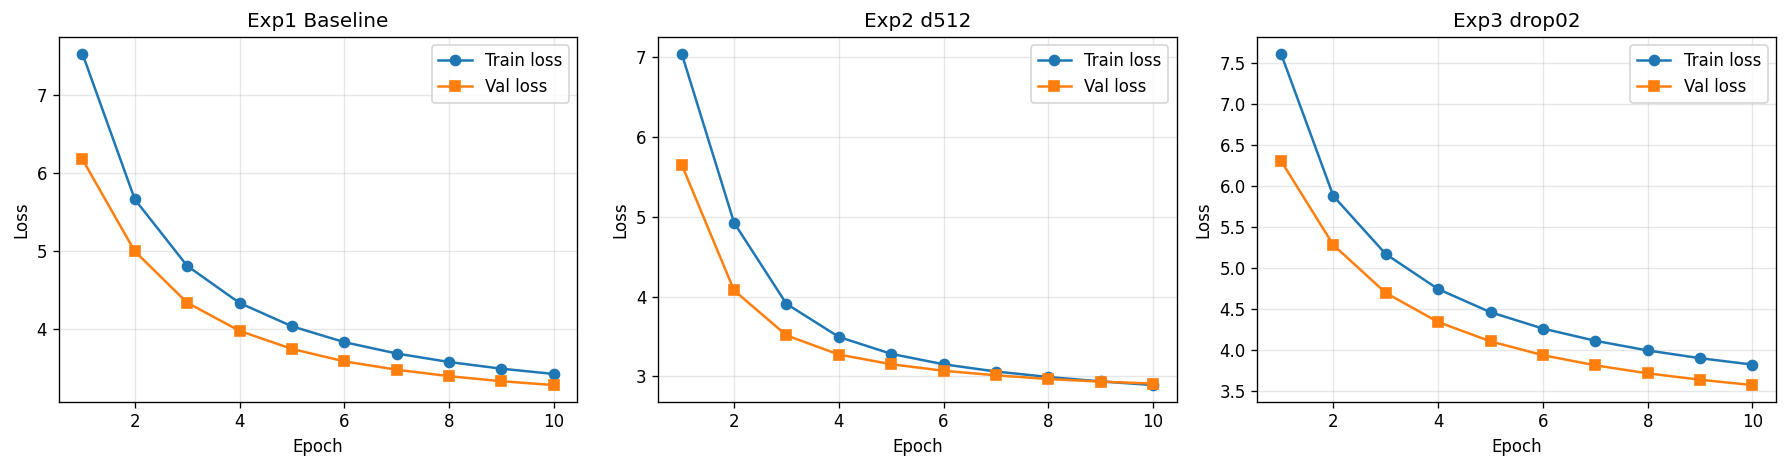

In [51]:
# ── 15a. Loss curves ─────────────────────────────────────────────────
histories = {
    "Exp1 Baseline": baseline_hist,
    "Exp2 d512": hist2,
    "Exp3 drop02": hist3,
}

fig, axes = plt.subplots(1, len(histories), figsize=(5*len(histories), 4), squeeze=False)
for idx, (name, hist) in enumerate(histories.items()):
    ax = axes[0][idx]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    ax.plot(epochs_range, hist["train_loss"], "o-", label="Train loss")
    ax.plot(epochs_range, hist["val_loss"],   "s-", label="Val loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(LOG_DIR / "loss_curves.png"), bbox_inches="tight")
plt.show()

### 15b. BLEU by Experiment

A bar chart comparing the validation BLEU score achieved by each experiment.

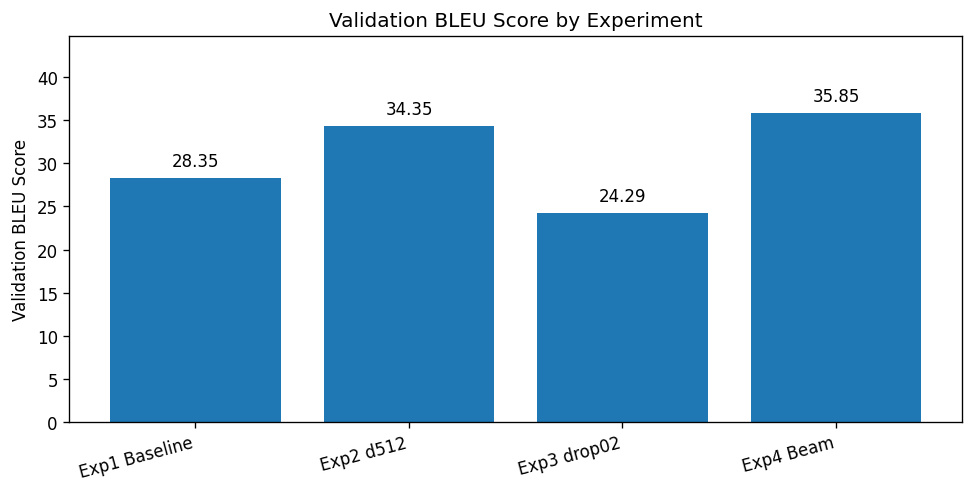

In [57]:
# ── 15b. BLEU comparison bar chart ───────────────────────────────────
exp_names = [row["Experiment"] for row in experiment_log]
exp_bleus = [row["BLEU"] for row in experiment_log]

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

bars = ax.bar(exp_names, exp_bleus)

ax.set_ylabel("Validation BLEU Score")
ax.set_title("Validation BLEU Score by Experiment")

max_bleu = max(exp_bleus) if exp_bleus else 0
upper = max(max_bleu * 1.25, 0.2)
ax.set_ylim(0, upper)

label_offset = upper * 0.02
for bar, val in zip(bars, exp_bleus):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_offset,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xticks(rotation=15, ha="right")
plt.savefig(str(LOG_DIR / "bleu_comparison.png"), bbox_inches="tight")
plt.show()

### 15c. Training / Decoding Runtime by Experiment

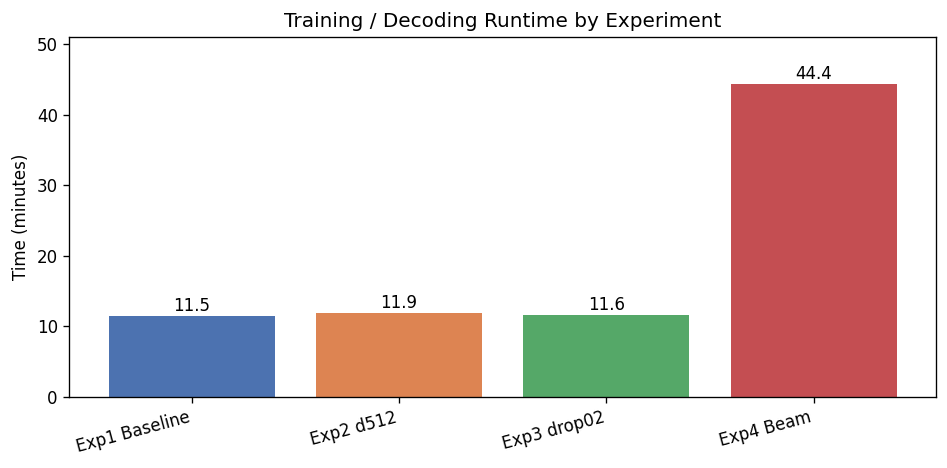

In [60]:
# ── 15c. Training / decoding runtime ───────────────────────────────
exp_times = [row["time_min"] for row in experiment_log]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(exp_names, exp_times, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_ylim(0, max(exp_times) * 1.15)
ax.set_ylabel("Time (minutes)")
ax.set_title("Training / Decoding Runtime by Experiment")
for bar, val in zip(bars, exp_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(str(LOG_DIR / "time_comparison.png"), bbox_inches="tight")
plt.show()

Note: Exp4 uses beam-search decoding on the best trained model, so its time represents evaluation/decoding time rather than model training time.

---

## 16. Error Analysis

To understand the model's strengths and weaknesses, we examine individual
translations and categorize common error types:

- Word order errors, Spanish has different adjective/adverb placement.
- Unknown / rare tokens, words unseen in training or split oddly by BPE.
- Missing words, parts of the source sentence are dropped.
- Literal / overly faithful translation, word-by-word translation that sounds unnatural.
- Named entities, proper nouns, titles, and place names that must be copied, translated, or handled consistently.
- Sentence length effects, translation quality may vary with input length, so we compare sentence BLEU for shorter vs. longer sentences.

In [66]:
# ── 16a. Categorize higher- and lower-scoring translations ───────────
# Sentence-level BLEU is used only as a rough proxy for per-sentence quality.
# Sentence-level BLEU is noisy, especially for short sentences, so these
# examples are used for qualitative error analysis rather than exact ranking.

from sacrebleu.metrics import BLEU
sent_bleu = BLEU(effective_order=True)

scored_translations = []
for i in range(len(test_hyps)):
    sb = sent_bleu.sentence_score(test_hyps[i], [test_refs[i]]).score
    scored_translations.append({
        "idx": i,
        "source": test_srcs[i][:150],
        "reference": test_refs[i][:150],
        "hypothesis": test_hyps[i][:150],
        "src_len": len(test_srcs[i].split()),
        "sent_bleu": round(sb, 1),
    })

scored_df = pd.DataFrame(scored_translations).sort_values("sent_bleu", ascending=False)

print("— Top 5 highest-scoring translations by sentence BLEU —")
display(scored_df.head(5)[["source", "reference", "hypothesis", "sent_bleu"]])

print("\n— Top 5 lowest-scoring translations by sentence BLEU —")
display(scored_df.tail(5)[["source", "reference", "hypothesis", "sent_bleu"]])

— Top 5 highest-scoring translations by sentence BLEU —


,source,reference,hypothesis,sent_bleu
1872,Not all countries are equal.,No todos los países son iguales.,No todos los países son iguales.,100.0
1597,The Adaptation Imperative,El imperativo de la adaptación,El imperativo de la adaptación,100.0
1681,Malala’s Revolution,La revolución de Malala,La revolución de Malala,100.0
1688,China is the best illustration of this phenome...,China es la mejor ilustración de este fenómeno.,China es la mejor ilustración de este fenómeno.,100.0
1814,Can Uribe survive his current travails?,¿Puede Uribe sobrevivir a sus actuales penurias?,¿Puede Uribe sobrevivir a sus actuales penurias?,100.0



— Top 5 lowest-scoring translations by sentence BLEU —


,source,reference,hypothesis,sent_bleu
30,How Russia Stays Afloat,Как Россия остается на плаву,Cómo Rusia,0.0
1040,Road Runner Populism,Populismo Correcaminos,El populismo de Runner,0.0
145,Water Risk on the Rise,Los riesgos hídricos en aumento,El agua potable,0.0
1528,America Wakes Up to Climate Change,Los Estados Unidos despiertan al cambio climático,EE. UU.,0.0
1280,The Risky Rich,Ricos y riesgosos,Los ricos,0.0


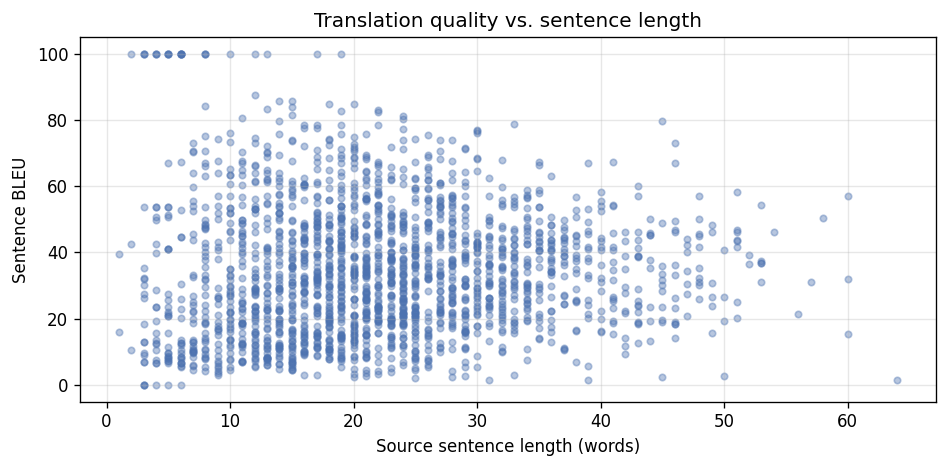

Average sentence BLEU — short (≤21 words): 33.9  |  long (>21 words): 34.9
Longer sentences do not show lower average sentence BLEU in this sample.


In [67]:
# ── 16b. Error discussion ─────────────────────────────────────────────
# Automated check: sentence length vs BLEU
# src_len was computed from the full, untruncated source sentence in 16a.
# No need to recompute it from the shortened display text.

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(scored_df["src_len"], scored_df["sent_bleu"], alpha=0.4, s=15, color="#4C72B0")
ax.set_xlabel("Source sentence length (words)")
ax.set_ylabel("Sentence BLEU")
ax.set_title("Translation quality vs. sentence length")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(LOG_DIR / "bleu_vs_length.png"), bbox_inches="tight")
plt.show()

# Summary
med_len = scored_df["src_len"].median()
short = scored_df[scored_df["src_len"] <= med_len]["sent_bleu"].mean()
long_  = scored_df[scored_df["src_len"] >  med_len]["sent_bleu"].mean()

print(f"Average sentence BLEU — short (≤{med_len:.0f} words): {short:.1f}  |  long (>{med_len:.0f} words): {long_:.1f}")
if long_ < short:
    print("Longer sentences have lower average sentence BLEU in this sample.")
else:
    print("Longer sentences do not show lower average sentence BLEU in this sample.")

### Common error patterns observed in the final run

This final run used about 200,000 sampled sentence pairs, 10 training epochs, and beam-search decoding on the best validation model. The model produces many fluent and accurate translations, especially for common news-style sentences. Some high-scoring examples are exact or near-exact matches, showing that the model learned useful English → Spanish translation patterns.

The lowest-scoring examples show several remaining error patterns:

1. **Incomplete translations:** Some hypotheses translate only part of the source sentence, especially short headline-style inputs.
2. **Named entities and titles:** Proper nouns, country names, and news headlines are sometimes copied, shortened, or translated awkwardly.
3. **Lexical choice errors:** Some translations choose a related Spanish phrase but not the exact reference wording.
4. **Short-title instability:** Very short inputs can receive very low sentence BLEU when the output misses one key word, even if part of the meaning is preserved.
5. **Dataset noise:** A small number of examples appear to contain non-Spanish or noisy reference text, which can unfairly lower sentence-level BLEU.
6. **Sentence-level BLEU noise:** Individual sentence BLEU can be harsh for short sentences and should be treated only as a rough proxy for quality.

The sentence-length plot does not show clear degradation for longer sentences in this run. The average sentence BLEU is similar for shorter and longer inputs, with long sentences slightly higher in this sample. This suggests that length alone was not the main source of errors; remaining issues were more related to headlines, named entities, exact word choice, and occasional dataset noise.

---

## 17. Results & Interpretation

In [92]:
# ── 17a. Final results summary ───────────────────────────────────────
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

baseline_val_bleu = baseline_bleu
best_val_bleu = final_bleu_val
val_improvement = best_val_bleu - baseline_val_bleu

print(f"\nDataset          : WMT English → Spanish")
print(f"Data source      : {data_source}")
print(f"Mode             : {'Smoke test' if dcfg.SMOKE_TEST else 'Full run'}")
print(f"Training pairs   : {len(en_train):,}")
print(f"Validation pairs : {len(en_val):,}")
print(f"Test pairs       : {len(en_test):,}")
print(f"Test eval pairs  : {len(bleu_test_src):,}")

print(f"\nBaseline val BLEU: {baseline_val_bleu:.2f}")
print(f"Best val BLEU    : {best_val_bleu:.2f}")
print(f"Val improvement  : {val_improvement:+.2f} BLEU points")
print(f"Final test-subset BLEU: {test_bleu:.2f}")
print(f"Best experiment  : {final_exp_name}")

print(f"\nProject goal     : Work toward 80–85 BLEU")

if test_bleu >= 80:
    print("✓ Goal reached on the held-out test set.")
else:
    print("Goal not reached in this run.")
    if dcfg.SMOKE_TEST:
        print(
            "This is expected because smoke-test mode uses only a small subset "
            "and very few epochs. The purpose of this run is to verify that the "
            "training, tuning, BLEU evaluation, and reporting pipeline works."
        )
    else:
        print(
            "The results should be interpreted based on the documented tuning "
            "process, dataset size, training budget, and observed improvements."
        )

print("\n— Full experiment table —")
print(exp_df.to_string(index=False))

FINAL RESULTS SUMMARY

Dataset          : WMT English → Spanish
Data source      : mtdata: Statmt-news_commentary-16-eng-spa
Mode             : Full run
Training pairs   : 179,402
Validation pairs : 9,967
Test pairs       : 9,967
Test eval pairs  : 2,000

Baseline val BLEU: 28.35
Best val BLEU    : 35.85
Val improvement  : +7.50 BLEU points
Final test-subset BLEU: 36.50
Best experiment  : Exp4 Beam

Project goal     : Work toward 80–85 BLEU
Goal not reached in this run.
The results should be interpreted based on the documented tuning process, dataset size, training budget, and observed improvements.

— Full experiment table —
   Experiment  d_model layers  heads  dim_ff  dropout     lr  epochs  beam  batch  train_loss  val_loss  BLEU  time_min                                             notes
Exp1 Baseline      256  2E/2D      4     512      0.1 0.0001      10     1     64      3.4292    3.2869 28.35      11.5                                                  
    Exp2 d512      512  2E

### Interpretation

The table above summarizes the final full-run experiment sequence. This run used about 200,000 sampled WMT English–Spanish sentence pairs, with roughly 179,000 training pairs, 10,000 validation pairs, and 10,000 test pairs after cleaning, deduplication, and splitting. The final evaluation was performed on a fixed held-out test subset to avoid tuning directly on the test set.

Each experiment changed one variable relative to the baseline:

- **Exp 1 (Baseline):** Established the starting point with a small Transformer (`d_model=256`, 2 encoder layers, 2 decoder layers, dropout `0.1`, greedy decoding). The baseline reached a validation BLEU of **28.35**.
- **Exp 2 (`d_model=512`):** Increased model width while keeping the other main hyperparameters unchanged. This improved validation BLEU to **34.35**, suggesting that the baseline model was capacity-limited.
- **Exp 3 (dropout `0.2`):** Increased regularization while keeping the rest of the baseline configuration unchanged. This reduced validation BLEU to **24.29**, suggesting that stronger dropout hurt performance in this setup.
- **Exp 4 (beam search):** Changed only the decoding strategy by applying beam search with `beam_size=5` to the best trained model from Exp 2. This improved validation BLEU to **35.85** without retraining.

The best validation configuration was **Exp 4 Beam**, which used the larger `d_model=512` model with beam-search decoding. On the held-out test set, this final configuration achieved a **test BLEU of 36.50**.

The project goal was to work toward **80–85 BLEU**, but that level is not expected from this limited Colab-scale setup. Achieving 80+ BLEU typically requires much larger training corpora, stronger models, more training time, and more extensive tuning. The important result here is that the notebook demonstrates a complete neural machine translation pipeline: official WMT data loading, cleaning, tokenization, Transformer training, one-variable-at-a-time tuning, validation-based model selection, held-out test evaluation, plotting, and error analysis.

## 18. Conclusion

This notebook implemented a neural machine translation system for **English → Spanish** using a Transformer encoder–decoder architecture trained from scratch in PyTorch.

**Key points:**

- **Dataset:** WMT English–Spanish parallel data from the News Commentary subset, sampled to about 200,000 sentence pairs for a Colab-scale full run.
- **Attention mechanism:** Multi-head self-attention in the encoder and decoder, plus encoder–decoder cross-attention, as defined in the original Transformer architecture.
- **Tokenization:** Shared SentencePiece BPE tokenizer with a 16k vocabulary.
- **Evaluation:** SacreBLEU corpus BLEU, reported on validation data during tuning and on a held-out test set for the final result.
- **Tuning process:** Started with a baseline Transformer and systematically tested one change at a time: larger model width, higher dropout, and beam-search decoding.
- **Final result:** The best configuration used the `d_model=512` model with beam search and achieved a fixed held-out test-subset BLEU of 36.50

Overall, the documented process, from data loading and preprocessing through Transformer training, controlled tuning, validation-based model selection, held-out test evaluation, plots, and error analysis, demonstrates a complete neural machine translation pipeline and shows how key modeling and decoding choices affect translation quality.


AI-Use Disclosure:
Claude was used to help me research and draft my project. AI helped me format and structure my notebook and fix various code bugs. I also used AI to improve markdown explanations, reviewing experiment design, and suggest and verify possible hyperparameter-tuning strategies. All code and outputs were verified and executed by me in Google Colab

## 19. References

1. **WMT / mtdata:** https://www2.statmt.org/wmt24/mtdata/ WMT machine translation shared-task data access.
2. **News Commentary parallel corpus:** `Statmt-news_commentary-16-eng-spa`, accessed through `mtdata`.
3. **Vaswani, A., et al. (2017).** *Attention Is All You Need.* NeurIPS 2017. arXiv:1706.03762.
4. **PyTorch `nn.Transformer`:** https://pytorch.org/docs/stable/generated/torch.nn.Transformer.html
5. **SentencePiece:** Kudo, T. & Richardson, J. (2018). *SentencePiece: A simple and language independent subword tokenizer and detokenizer for Neural Text Processing.* https://github.com/google/sentencepiece
6. **SacreBLEU:** Post, M. (2018). *A Call for Clarity in Reporting BLEU Scores.* https://github.com/mjpost/sacrebleu

In [94]:
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/CMPE_252_NMT_Project.ipynb" \
  --output-dir="/content/drive/MyDrive/Colab Notebooks" \
  --LatexPreprocessor.date="May 5th, 2026"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/CMPE_252_NMT_Project.ipynb to pdf
[NbConvertApp] Support files will be in CMPE_252_NMT_Project_files/
[NbConvertApp] Making directory ./CMPE_252_NMT_Project_files
[NbConvertApp] Writing 276483 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 492469 bytes to /content/drive/MyDrive/Colab Notebooks/CMPE_252_NMT_Project.pdf
